# Car Colour Detection Model

## Objective
This project predicts vehicle colours from traffic images, counts vehicles and people at traffic signals, and highlights vehicles based on colour.

## Features
- Vehicle Colour Classification using CNN
- Vehicle Counting using YOLOv8
- People Counting using YOLOv8
- Traffic Image Analysis
- Gradio GUI Interface
- Confusion Matrix Evaluation
- Accuracy and Loss Visualization

## Problem Statement

Traffic monitoring is an essential component of intelligent transportation systems. Accurate identification of vehicle colours, counting vehicles, and monitoring pedestrian activity help improve traffic management, urban planning, and road safety.

The objective of this project is to develop a deep learning-based traffic analysis system that can:

- Predict the colour of vehicles from traffic images using a Convolutional Neural Network (CNN).
- Detect and count vehicles and pedestrians using the YOLOv8 object detection model.
- Highlight blue vehicles with **red bounding boxes** and all other vehicles with **blue bounding boxes**.
- Display the total number of vehicles and people detected in each image.
- Provide an interactive Gradio-based graphical user interface (GUI) for easy image upload and result visualization.

This integrated system demonstrates how image classification and object detection can be combined to perform intelligent traffic analysis.

In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.7 MB/s eta 0:00:00


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from ultralytics import YOLO

from collections import Counter

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import gradio as gr

E0000 00:00:1783427214.726178      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783427214.822657      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783427215.561570      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783427215.561626      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783427215.561630      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783427215.561632      16 computation_placer.cc:177] computation placer already registered. Please check linka

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset Description

### Vehicle Colour Classification Dataset

The project uses a vehicle colour classification dataset consisting of images of cars belonging to multiple colour categories.

### Colour Classes

- Black
- Blue
- Brown
- Green
- Grey
- Orange
- Red
- Silver
- White
- Yellow

## Data Preprocessing

The dataset is preprocessed using the following steps:

1. Images resized to 224 × 224 pixels.
2. Data loaded using TensorFlow image_dataset_from_directory().
3. Pixel values normalized to [0,1].
4. Dataset split into:
   - Training
   - Validation
   - Testing
5. Batch size = 32

In [3]:
IMG_SIZE = (224,224)        # Image dimensions for CNN input
BATCH_SIZE = 32             # Number of images processed in one batch

train_ds = tf.keras.utils.image_dataset_from_directory(r"/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(r"/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 7267 files belonging to 15 classes.
Found 1550 files belonging to 15 classes.
['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']


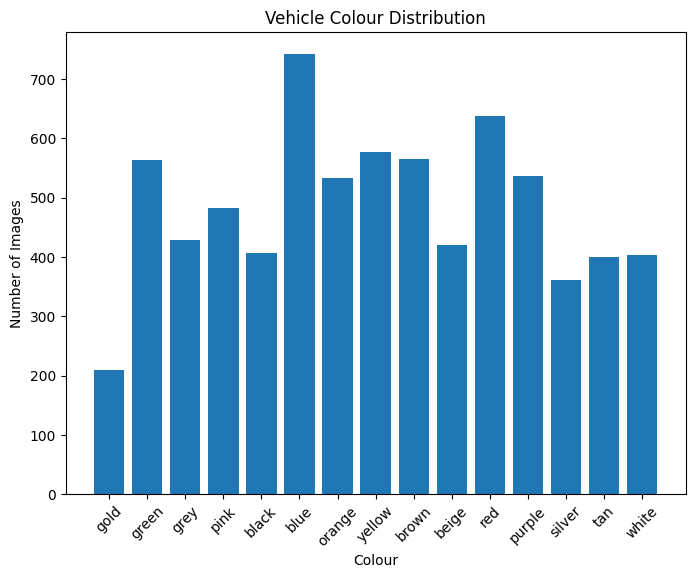

In [4]:
from collections import Counter

labels = []

for images, y in train_ds:
    labels.extend(y.numpy())

count = Counter(labels)

plt.figure(figsize=(8,6))
plt.bar(
    [class_names[i] for i in count.keys()],
    count.values()
)

plt.title("Vehicle Colour Distribution")
plt.xlabel("Colour")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

## CNN Model Architecture

A Convolutional Neural Network (CNN) is used for vehicle color classification.

Components:
- Convolution Layers
- Max Pooling Layers
- Dense Layers
- Dropout Layer

Output:
15 vehicle color classes


## Feature Engineering

Instead of manually extracting colour histograms or handcrafted features,
the CNN automatically learns colour-related visual patterns from images.

Learned features include:

- Dominant vehicle colour
- Colour intensity
- Colour distribution
- Visual texture information

## Model Selection

Two deep learning models are used in this project because they solve different tasks.

### Model Comparison

| Model | Purpose | Reason for Selection |
|--------|---------|----------------------|
| CNN | Vehicle colour classification | Learns image features and predicts vehicle colours with good accuracy. |
| YOLOv8 | Vehicle and pedestrian detection | Detects multiple objects quickly and accurately in a single image. |

Traditional image processing methods, such as colour thresholding, are sensitive to lighting conditions and shadows. A CNN provides more reliable colour classification, while YOLOv8 offers fast and accurate object detection. Combining both models improves the overall performance of the traffic analysis system.

### CNN for Vehicle Colour Classification

A Convolutional Neural Network (CNN) is selected because it is highly effective for image classification tasks. CNNs automatically learn colour, texture, and shape features from images through convolution and pooling operations.

### YOLOv8 for Object Detection

YOLOv8 (You Only Look Once Version 8) is used for vehicle and pedestrian detection because it performs real-time object detection with high accuracy and speed.

### Combined System

The complete pipeline works as follows:

1. YOLOv8 detects vehicles and pedestrians.
2. Each detected vehicle is cropped.
3. The CNN predicts the vehicle colour.
4. Blue vehicles are highlighted with **red bounding boxes**.
5. Other vehicles are highlighted with **blue bounding boxes**.
6. The total number of vehicles and pedestrians is displayed on the output image.

This combination provides an efficient end-to-end intelligent traffic analysis system.

In [5]:
# CNN architecture for colour classification
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255,                       # Normalize pixels
                              input_shape=(224,224,3)),      

    tf.keras.layers.Conv2D(32,3,activation='relu'),         
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Training Configuration

The CNN model is trained using the following configuration:

| Parameter | Value |
|-----------|-------|
| Optimizer | Adam |
| Loss Function | Sparse Categorical Crossentropy |
| Metrics | Accuracy |
| Batch Size | 32 |
| Image Size | 224 × 224 |
| Epochs | 10 |

The Adam optimizer is chosen because it provides fast convergence and stable training for image classification tasks.

## Model Training

The Convolutional Neural Network (CNN) is trained on the preprocessed vehicle colour dataset. 
During training, the model learns colour-specific visual features by minimizing the classification loss and 
maximizing prediction accuracy.

The training configuration is as follows:
- Optimizer: Adam
- Loss Function: Sparse Categorical Crossentropy
- Metric: Accuracy
- Epochs: 10

In [6]:
# Train the CNN model on the training dataset
# Validate performance after each epoch

history = model.fit(                         
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.5930 - loss: 1.2085 - val_accuracy: 0.7148 - val_loss: 0.8101
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 459s 2s/step - accuracy: 0.7588 - loss: 0.6985 - val_accuracy: 0.7465 - val_loss: 0.6828
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.8189 - loss: 0.5181 - val_accuracy: 0.7858 - val_loss: 0.6052
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - accuracy: 0.8690 - loss: 0.3983 - val_accuracy: 0.7852 - val_loss: 0.6308
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.9132 - loss: 0.2448 - val_accuracy: 0.7394 - val_loss: 0.9072
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.9546 - loss: 0.1383 - val_accuracy: 0.7974 - val_loss: 0.7805
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.9609 - loss: 0.1306 - val_accuracy: 0.7548 - val_loss: 1.0520
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.9762 - loss: 0.0827 - val_accu

In [7]:
# Save the trained CNN model for future inference
model.save("car_color_classifier.keras")

## Training Performance Visualization

The following plots show:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

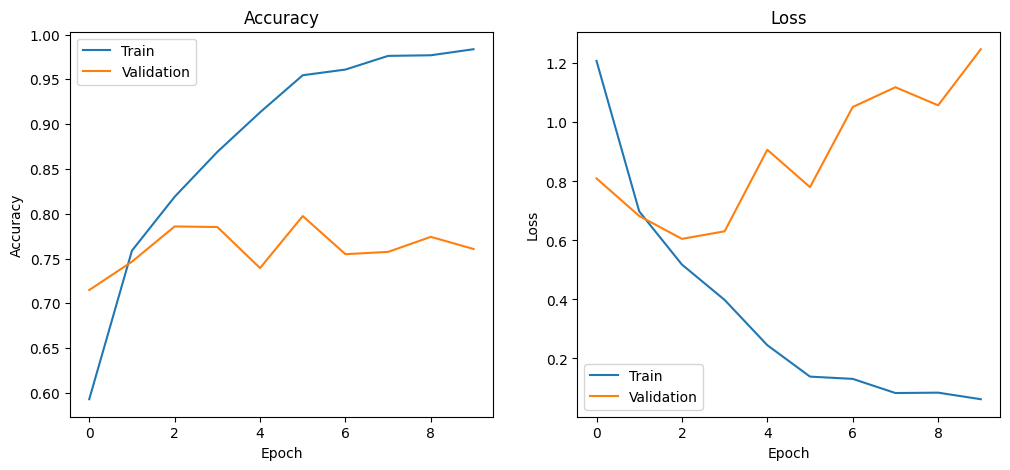

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [9]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/test",
    image_size=(224,224),
    batch_size=32
)

test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

Found 1556 files belonging to 15 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 27s 554ms/step - accuracy: 0.7590 - loss: 1.3096
Test Accuracy: 0.7589974403381348


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step


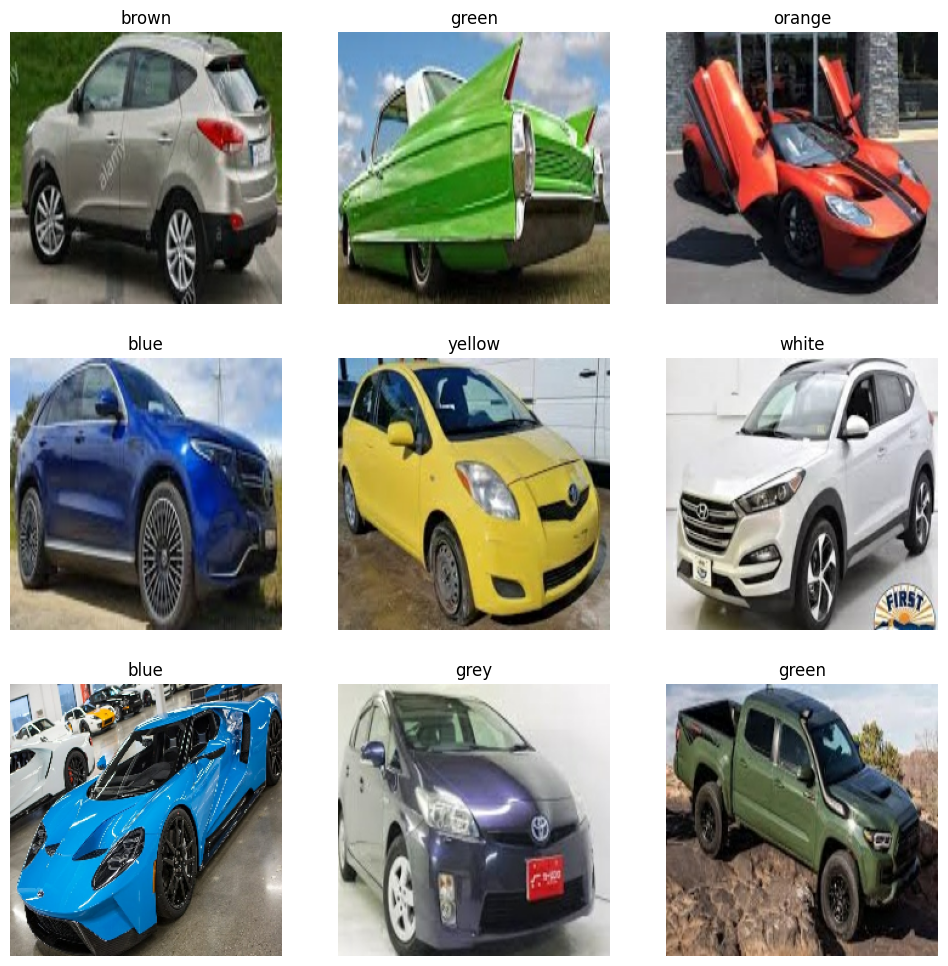

In [10]:
for images, labels in test_ds.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(12,12))

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        pred_class = class_names[
            np.argmax(predictions[i])
        ]

        plt.title(pred_class)

        plt.axis("off")

plt.show()

In [11]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", round(test_acc * 100, 2), "%")

49/49 ━━━━━━━━━━━━━━━━━━━━ 27s 547ms/step - accuracy: 0.7590 - loss: 1.3096
Test Accuracy: 75.9 %


## Model Evaluation

The confusion matrix is used to evaluate classification performance across all color classes.

## Model Evaluation

The trained CNN model is evaluated using multiple performance metrics.

The evaluation includes:

- Test Accuracy
- Test Loss
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a comprehensive understanding of the model's classification performance across all vehicle colour classes.

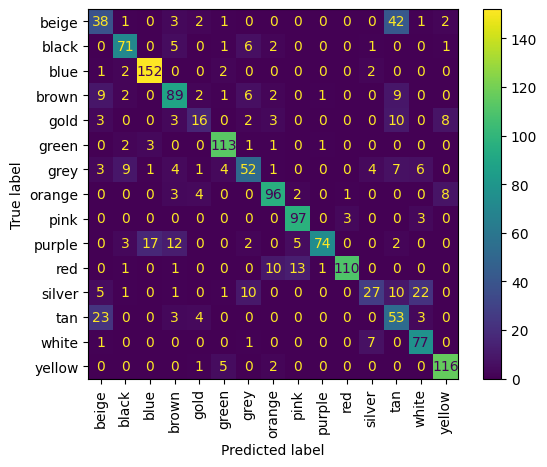

In [12]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=90)
plt.show()

In [13]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       beige       0.46      0.42      0.44        90
       black       0.77      0.82      0.79        87
        blue       0.88      0.96      0.92       159
       brown       0.72      0.74      0.73       121
        gold       0.53      0.36      0.43        45
       green       0.88      0.93      0.91       121
        grey       0.65      0.57      0.60        92
      orange       0.82      0.84      0.83       114
        pink       0.83      0.94      0.88       103
      purple       0.96      0.64      0.77       115
         red       0.96      0.81      0.88       136
      silver       0.66      0.35      0.46        77
         tan       0.40      0.62      0.48        86
       white       0.69      0.90      0.78        86
      yellow       0.86      0.94      0.90       124

    accuracy                           0.76      1556
   macro avg       0.74      0.72      0.72      1556
weighted avg       0.77   

## Model Comparison

Two deep learning models are used in this project because they perform different tasks.

| Model | Purpose | Advantages |
|--------|----------|------------|
| CNN | Vehicle Colour Classification | Learns colour-specific visual features with high accuracy |
| YOLOv8 | Vehicle and Pedestrian Detection | Performs fast real-time object detection |

The CNN predicts vehicle colours after YOLOv8 detects the vehicles.

Combining both models enables accurate traffic analysis while maintaining real-time performance.

In [14]:
model.save("car_color_classifier.keras")

## Results Summary

The proposed system successfully performs the following tasks:

- Classifies vehicle colours using a Convolutional Neural Network (CNN).
- Detects vehicles and pedestrians using YOLOv8.
- Counts the total number of vehicles and pedestrians in traffic images.
- Highlights blue vehicles with **red bounding boxes** and all other vehicles with **blue bounding boxes**.
- Provides a user-friendly Gradio GUI for uploading and analysing traffic images.

Overall, the integrated CNN and YOLOv8 pipeline demonstrates effective performance for intelligent traffic monitoring and vehicle colour detection.

##  Vehicle and Pedestrian Detection
YOLOv8 is used to:


* Detect vehicles in traffic scenes.
* Detect pedestrians at the traffic signal.
* Count the total number of vehicles.
* Count the total number of pedestrians

The detected vehicles are then passed to the CNN model to:

* Classify each vehicle's colour.
* Identify blue vehicles.
* Display the colour of every detected vehicle.


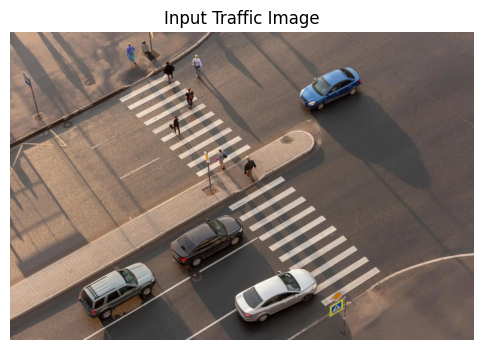

Vehicles Detected : 4
Blue Cars         : 1
People Detected   : 7


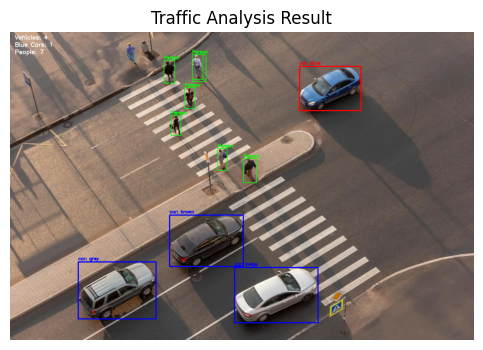

In [15]:
from glob import glob
from PIL import Image

# Load YOLO model
yolo = YOLO("yolov8n.pt")

# Test image
image_path = glob("/kaggle/input/datasets/*/car-colour/image 1.jpg")[0]

# Read image
image = cv2.imread(image_path)
output = image.copy()

# Show original image
plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Input Traffic Image")
plt.axis("off")
plt.show()

# Run YOLO
results = yolo(image_path, verbose=False)

total_cars = 0
total_people = 0
blue_cars = 0

for r in results:

    for box in r.boxes:

        cls = int(box.cls[0])
        label = yolo.names[cls]

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Count people
        if label == "person":

            total_people += 1

            cv2.rectangle(output,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(output,"Person",
                        (x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0,255,0),
                        2)

        # Detect only cars
        elif label in ["car"]:

            total_cars += 1

            crop = image[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            # CNN preprocessing
            crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            crop = cv2.resize(crop,(224,224))
            crop = crop.astype("float32")
            crop = np.expand_dims(crop,axis=0)

            # Predict colour using your trained CNN
            pred = model.predict(crop, verbose=0)

            colour = class_names[np.argmax(pred)]

            is_blue = colour.lower() == "blue"
            box_colour = (0,0,255) if is_blue else (255,0,0)
            blue_cars += int(is_blue)

            cv2.rectangle(output, (x1, y1), (x2, y2), box_colour, 3)
            cv2.putText(output, f"{label}: {colour}", (x1, y1-8),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_colour, 2)

# Statistics
stats = [
    f"Vehicles: {total_cars}",
    f"Blue Cars: {blue_cars}",
    f"People: {total_people}"
]

for i, text in enumerate(stats):
    cv2.putText(output, text, (20, 30 + i*30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

print(f"Vehicles Detected : {total_cars}")
print(f"Blue Cars         : {blue_cars}")
print(f"People Detected   : {total_people}")

plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Traffic Analysis Result")
plt.axis("off")
plt.show()

## Graphical User Interface (GUI)

Features:

- Upload traffic image
- Preview uploaded image
- Detect vehicle colors
- Count vehicles
- Count pedestrians
- Display processed image

In [16]:
def detect_traffic(image_path):

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = yolo(image_path)

    vehicle_count = 0
    people_count = 0

    blue_cars = 0
    other_cars = 0
    
    report = ""

    for r in results:

        boxes = r.boxes.xyxy.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()

        for box, cls in zip(boxes, classes):

            class_name = yolo.names[int(cls)]

            x1, y1, x2, y2 = map(int, box)

            # Count people
            if class_name == "person":
                people_count += 1
                continue

            # Detect vehicles
            if class_name in ["car", "truck", "bus", "motorcycle"]:

                vehicle_count += 1

                car_crop = image_rgb[y1:y2, x1:x2]

                if car_crop.size == 0:
                    continue

                car_crop = cv2.resize(car_crop, (224, 224))
                car_crop = np.expand_dims(car_crop, axis=0)

                prediction = model.predict(car_crop, verbose=0)

                color = class_names[np.argmax(prediction)]
                
                # Blue car -> RED rectangle
                # Other colors -> BLUE rectangle

                if color.lower() == "blue":
                    box_color = (255, 0, 0)
                    blue_cars += 1
                else:
                    box_color = (0, 0, 255)
                    other_cars += 1

                cv2.rectangle(
                    image_rgb,
                    (x1, y1),
                    (x2, y2),
                    box_color,
                    3
                )

                cv2.putText(
                    image_rgb,
                    color,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    box_color,
                    2
                )

                report += f"Vehicle {vehicle_count}: {color}\n"

    summary = (
        f"Total Vehicles: {vehicle_count}\n"
        f"Blue Cars: {blue_cars}\n"
        f"Other Cars: {other_cars}\n"
        f"People Detected: {people_count}\n\n"
        + report
    )

    return image_rgb, summary

In [17]:
demo = gr.Interface(
    fn=detect_traffic,
    inputs=gr.Image(type="filepath"),
    outputs=[
        gr.Image(height=250),
        gr.Textbox(lines=6)
    ],
    title="Car Color Detection System"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://e500441afb05d03898.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Insights

Key observations from this project include:

- CNN successfully learns colour-specific visual features.
- Normalization improves training stability.
- YOLOv8 performs fast and accurate object detection.
- Combining CNN with YOLOv8 provides a complete traffic analysis pipeline.
- Training and validation accuracy indicate good model learning without significant overfitting.

## Future Scope

Future improvements include:

- Video-based real-time traffic monitoring.
- Multi-camera traffic surveillance.
- Vehicle make and model recognition.
- Vehicle speed estimation.
- Automatic traffic violation detection.
- Deployment using Streamlit or Flask.
- Cloud deployment for smart city applications.